# Few-shot Learning

Test accuracy of the expand-and-sparsify classification pipeline as a function of the number of training exposures per category.

Training is done by the stand-alone script `r3_few_shot_training.py`, which pickles the results to `data/r3_few_shot_results.pkl`. This notebook loads those results and generates the figures.

In [23]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

## Load results

Run `python r3_few_shot_training.py` from the repo root to (re)generate the pickle.

In [24]:
with open('data/r3_few_shot_results.pkl', 'rb') as f:
    results = pickle.load(f)

params = results['params']
single = results['single']
binary = results['binary']

all_train_accs_single    = single['train_accs']
all_test_accs_single     = single['test_accs']
all_test_accs_single_svm = single['test_accs_svm']

all_train_accs_binary    = binary['train_accs']
all_test_accs_binary     = binary['test_accs']
all_test_accs_binary_svm = binary['test_accs_svm']

print(f"Parameters: {params}")
print(f"Single — shape: {all_test_accs_single.shape}, picks: {single['n_picks']}")
print(f"Binary — shape: {all_test_accs_binary.shape}, picks: {binary['n_picks']}")

Parameters: {'n_hd': 10000, 'p_hd': 0.025, 'd': 0.5, 'p': 0.01, 'normalized': 'raw', 'n_times': 10}
Single — shape: (10, 148), picks: 148
Binary — shape: (10, 100), picks: 100


## Results

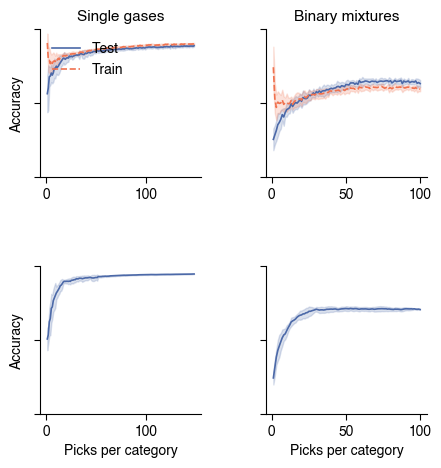

In [25]:
fig, ax = plt.subplots(2, 2, figsize=(5, 5),
                       gridspec_kw={'wspace': 0.4, 'hspace': 0.6},
                       sharey='row')

picks = np.arange(1, all_test_accs_single.shape[1] + 1)
picks_b = np.arange(1, all_test_accs_binary.shape[1] + 1)

# --- Row 1: Expand & Sparsify ---
# Single gases
ax0 = ax[0, 0]
mean_test = all_test_accs_single.mean(axis=0)
std_test  = all_test_accs_single.std(axis=0)
mean_train = all_train_accs_single.mean(axis=0)
std_train  = all_train_accs_single.std(axis=0)
ax0.plot(picks, mean_test, '-', color='C0', label='Test', clip_on=False)
ax0.fill_between(picks, mean_test - std_test, mean_test + std_test,
                 alpha=0.2, color='C0', clip_on=False)
ax0.plot(picks, mean_train, '--', color='C1', label='Train', clip_on=False)
ax0.fill_between(picks, mean_train - std_train, mean_train + std_train,
                 alpha=0.2, color='C1', clip_on=False)
ax0.set_ylabel('Accuracy')
ax0.set_ylim(0, 1)
ax0.set_yticks([0, 0.5, 1])
ax0.legend(loc='upper left', frameon=False, fontsize=10)

# Binary mixtures
ax1 = ax[0, 1]
mean_test_b = all_test_accs_binary.mean(axis=0)
std_test_b  = all_test_accs_binary.std(axis=0)
mean_train_b = all_train_accs_binary.mean(axis=0)
std_train_b  = all_train_accs_binary.std(axis=0)
ax1.plot(picks_b, mean_test_b, '-', color='C0', label='Test', clip_on=False)
ax1.fill_between(picks_b, mean_test_b - std_test_b, mean_test_b + std_test_b,
                 alpha=0.2, color='C0', clip_on=False)
ax1.plot(picks_b, mean_train_b, '--', color='C1', label='Train', clip_on=False)
ax1.fill_between(picks_b, mean_train_b - std_train_b, mean_train_b + std_train_b,
                 alpha=0.2, color='C1', clip_on=False)
ax1.set_ylim(0, 1)
ax1.set_yticks([0, 0.5, 1], labels=[])

# --- Row 2: RBF SVM ---
# Single gases - RBF SVM
ax2 = ax[1, 0]
mean_svm_s = np.nanmean(all_test_accs_single_svm, axis=0)
std_svm_s  = np.nanstd(all_test_accs_single_svm, axis=0)
ax2.plot(picks, mean_svm_s, '-', color='C0', label='Test', clip_on=False)
ax2.fill_between(picks, mean_svm_s - std_svm_s, mean_svm_s + std_svm_s,
                 alpha=0.2, color='C0', clip_on=False)
ax2.set_xlabel('Picks per category')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.set_yticks([0, 0.5, 1])

# Binary mixtures - RBF SVM
ax3 = ax[1, 1]
mean_svm_b = np.nanmean(all_test_accs_binary_svm, axis=0)
std_svm_b  = np.nanstd(all_test_accs_binary_svm, axis=0)
ax3.plot(picks_b, mean_svm_b, '-', color='C0', label='Test', clip_on=False)
ax3.fill_between(picks_b, mean_svm_b - std_svm_b, mean_svm_b + std_svm_b,
                 alpha=0.2, color='C0', clip_on=False)
ax3.set_xlabel('Picks per category')
ax3.set_ylim(0, 1)
ax3.set_yticks([0, 0.5, 1], labels=[])

# Column titles (top row)
ax0.set_title('Single gases', fontsize=11)
ax1.set_title('Binary mixtures', fontsize=11)

plt.savefig('figs/R3-few_shot_learning.pdf', bbox_inches='tight')
plt.show()

## Expand & Sparsify only

Same few-shot curves as above, but plotting only the expand & sparsify train/test accuracy (no SVM row).

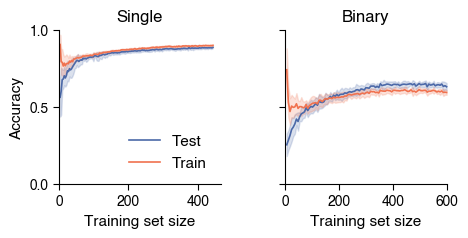

In [43]:
n_cats_single = 3
n_cats_binary = 6

fig, ax = plt.subplots(1, 2, figsize=(5, 2),
                       gridspec_kw={'wspace': 0.4},
                       sharey=True)

picks = np.arange(1, all_test_accs_single.shape[1] + 1) * n_cats_single
picks_b = np.arange(1, all_test_accs_binary.shape[1] + 1) * n_cats_binary

# Single gases
ax0 = ax[0]
mean_test = all_test_accs_single.mean(axis=0)
std_test  = all_test_accs_single.std(axis=0)
mean_train = all_train_accs_single.mean(axis=0)
std_train  = all_train_accs_single.std(axis=0)
ax0.plot(picks, mean_test, '-', color='C0', label='Test', clip_on=False)
ax0.fill_between(picks, mean_test - std_test, mean_test + std_test,
                 alpha=0.2, color='C0', clip_on=False)
ax0.plot(picks, mean_train, '-', color='C1', label='Train', clip_on=False)
ax0.fill_between(picks, mean_train - std_train, mean_train + std_train,
                 alpha=0.2, color='C1', clip_on=False)
ax0.set_xlabel('Training set size', fontsize=11)
ax0.set_ylabel('Accuracy', fontsize=11)
ax0.set_ylim(0, 1)
ax0.set_xlim(0, None)
ax0.set_ylim(0, 1)
ax0.set_xticks([0, 200, 400])
ax0.set_yticks([0, 0.5, 1])
ax0.set_title('Single', fontsize=12)
ax0.legend(loc='lower right', frameon=False, fontsize=11)

# Binary mixtures
ax1 = ax[1]
mean_test_b = all_test_accs_binary.mean(axis=0)
std_test_b  = all_test_accs_binary.std(axis=0)
mean_train_b = all_train_accs_binary.mean(axis=0)
std_train_b  = all_train_accs_binary.std(axis=0)
ax1.plot(picks_b, mean_test_b, '-', color='C0', label='Test', clip_on=False)
ax1.fill_between(picks_b, mean_test_b - std_test_b, mean_test_b + std_test_b,
                 alpha=0.2, color='C0', clip_on=False)
ax1.plot(picks_b, mean_train_b, '-', color='C1', label='Train', clip_on=False)
ax1.fill_between(picks_b, mean_train_b - std_train_b, mean_train_b + std_train_b,
                 alpha=0.2, color='C1', clip_on=False)
ax1.set_xlabel('Training set size', fontsize=11)
ax1.set_xlim(0, 600)
ax1.set_ylim(0, 1)
ax1.set_xticks([0, 200, 400, 600])
ax1.set_yticks([0, 0.5, 1])
ax1.set_title('Binary', fontsize=12)

plt.savefig('figs/few_shot_learning.pdf', bbox_inches='tight')
plt.show()

## Effect of learning rate *p*

Side-by-side comparison of *p* = 0.1 (left) and *p* = 0.01 (right).
Top row: single gases, bottom row: binary mixtures.

In [45]:
# Load p=0.1 results
with open('data/r3_few_shot_results_p01.pkl', 'rb') as f:
    results_p01 = pickle.load(f)

single_p01 = results_p01['single']
binary_p01 = results_p01['binary']

print(f"p=0.1 params: {results_p01['params']}")
print(f"Single — shape: {single_p01['test_accs'].shape}, picks: {single_p01['n_picks']}")
print(f"Binary — shape: {binary_p01['test_accs'].shape}, picks: {binary_p01['n_picks']}")

p=0.1 params: {'n_hd': 10000, 'p_hd': 0.025, 'd': 0.5, 'p': 0.1, 'normalized': 'raw', 'n_times': 10}
Single — shape: (10, 148), picks: 148
Binary — shape: (10, 100), picks: 100


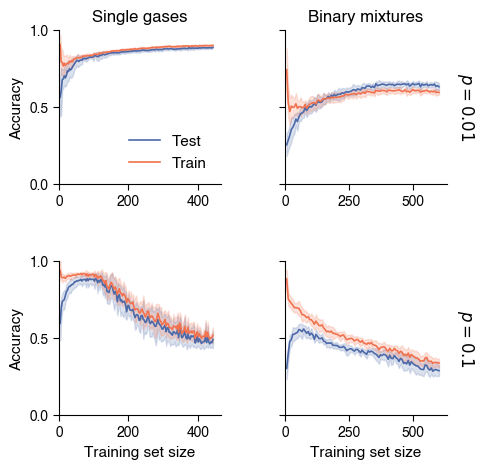

In [52]:
n_cats_single = 3
n_cats_binary = 6

fig, ax = plt.subplots(2, 2, figsize=(5, 5),
                       gridspec_kw={'wspace': 0.4, 'hspace': 0.5},
                       sharey=True)

# x-axes: total number of training sequences
x_single = np.arange(1, all_test_accs_single.shape[1] + 1) * n_cats_single
x_binary = np.arange(1, all_test_accs_binary.shape[1] + 1) * n_cats_binary
x_single_p01 = np.arange(1, single_p01['test_accs'].shape[1] + 1) * n_cats_single
x_binary_p01 = np.arange(1, binary_p01['test_accs'].shape[1] + 1) * n_cats_binary

# Rows: p values, Columns: datasets
# row 0 = p=0.01, row 1 = p=0.1
row_data = [
    (single, binary, x_single, x_binary),        # p=0.01
    (single_p01, binary_p01, x_single_p01, x_binary_p01),  # p=0.1
]

for row, (d_single, d_binary, xs, xb) in enumerate(row_data):
    for col, (data, x) in enumerate([(d_single, xs), (d_binary, xb)]):
        a = ax[row, col]
        mt = data['test_accs'].mean(axis=0)
        st = data['test_accs'].std(axis=0)
        mr = data['train_accs'].mean(axis=0)
        sr = data['train_accs'].std(axis=0)
        a.plot(x, mt, '-', color='C0', label='Test', clip_on=False)
        a.fill_between(x, mt - st, mt + st, alpha=0.2, color='C0', clip_on=False)
        a.plot(x, mr, '-', color='C1', label='Train', clip_on=False)
        a.fill_between(x, mr - sr, mr + sr, alpha=0.2, color='C1', clip_on=False)
        a.set_xlim(0, None)
        a.set_ylim(0, 1)
        a.set_yticks([0, 0.5, 1])
        if row == 1:
            a.set_xlabel('Training set size', fontsize=11)
        if col == 0:
            a.set_ylabel('Accuracy', fontsize=11)

# Column titles
ax[0, 0].set_title('Single gases', fontsize=12)
ax[0, 1].set_title('Binary mixtures', fontsize=12)

# Row labels on the right
for row, label in enumerate(['$p = 0.01$', '$p = 0.1$']):
    ax[row, 1].annotate(label, xy=(1.05, 0.5), xycoords='axes fraction',
                         fontsize=12, ha='left', va='center', rotation=-90)

# Legend on top-left panel
ax[0, 0].legend(loc='lower right', frameon=False, fontsize=11)

plt.savefig('figs/R3-few_shot_p_comparison.pdf', bbox_inches='tight')
plt.show()

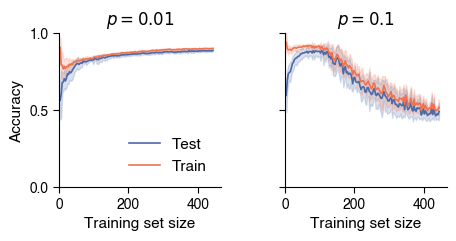

p = 0.01: best test accuracy = 0.887 ± 0.008 at training set size = 375
p = 0.1: best test accuracy = 0.886 ± 0.033 at training set size = 105


In [57]:
n_cats_single = 3

fig, ax = plt.subplots(1, 2, figsize=(5, 2),
                       gridspec_kw={'wspace': 0.4},
                       sharey=True)

x_single = np.arange(1, all_test_accs_single.shape[1] + 1) * n_cats_single
x_single_p01 = np.arange(1, single_p01['test_accs'].shape[1] + 1) * n_cats_single

for col, (data, x, p_label) in enumerate([
    (single, x_single, '$p = 0.01$'),
    (single_p01, x_single_p01, '$p = 0.1$'),
]):
    a = ax[col]
    mt = data['test_accs'].mean(axis=0)
    st = data['test_accs'].std(axis=0)
    mr = data['train_accs'].mean(axis=0)
    sr = data['train_accs'].std(axis=0)
    a.plot(x, mt, '-', color='C0', label='Test', clip_on=False)
    a.fill_between(x, mt - st, mt + st, alpha=0.2, color='C0', clip_on=False)
    a.plot(x, mr, '-', color='C1', label='Train', clip_on=False)
    a.fill_between(x, mr - sr, mr + sr, alpha=0.2, color='C1', clip_on=False)
    a.set_xlim(0, None)
    a.set_ylim(0, 1)
    a.set_xticks([0, 200, 400])
    a.set_yticks([0, 0.5, 1])
    a.set_xlabel('Training set size', fontsize=11)
    a.set_title(p_label, fontsize=12)

ax[0].set_ylabel('Accuracy', fontsize=11)
ax[0].legend(loc='lower right', frameon=False, fontsize=11)

plt.savefig('figs/few_shot_single.pdf', bbox_inches='tight')
plt.show()

# Best test accuracy for each p
for p_val, data in [('0.01', single), ('0.1', single_p01)]:
    mean_test = data['test_accs'].mean(axis=0)
    std_test = data['test_accs'].std(axis=0)
    best_idx = np.argmax(mean_test)
    best_size = (best_idx + 1) * n_cats_single
    print(f"p = {p_val}: best test accuracy = {mean_test[best_idx]:.3f} ± {std_test[best_idx]:.3f} at training set size = {best_size}")

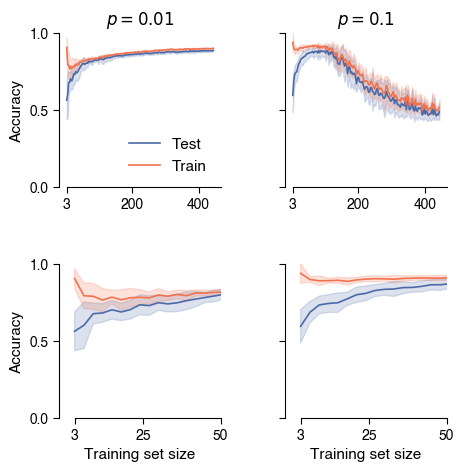

In [77]:
n_cats_single = 3

fig, ax = plt.subplots(2, 2, figsize=(5, 5),
                       gridspec_kw={'wspace': 0.4, 'hspace': 0.5},
                       sharey=True)

x_single = np.arange(1, all_test_accs_single.shape[1] + 1) * n_cats_single
x_single_p01 = np.arange(1, single_p01['test_accs'].shape[1] + 1) * n_cats_single

for row in range(2):
    for col, (data, x, p_label) in enumerate([
        (single, x_single, '$p = 0.01$'),
        (single_p01, x_single_p01, '$p = 0.1$'),
    ]):
        a = ax[row, col]
        mt = data['test_accs'].mean(axis=0)
        st = data['test_accs'].std(axis=0)
        mr = data['train_accs'].mean(axis=0)
        sr = data['train_accs'].std(axis=0)
        a.plot(x, mt, '-', color='C0', label='Test')
        a.fill_between(x, mt - st, mt + st, alpha=0.2, color='C0')
        a.plot(x, mr, '-', color='C1', label='Train')
        a.fill_between(x, mr - sr, mr + sr, alpha=0.2, color='C1')
        a.set_ylim(0, 1)
        a.set_yticks([0, 0.5, 1])
        if row == 0:
            a.set_xlim(-20, None)
            a.set_xticks([3, 200, 400])
            a.set_title(p_label, fontsize=12)
        else:
            a.set_xlim(-2, 50)
            a.set_xticks([3, 25, 50])
            a.set_xlabel('Training set size', fontsize=11)
        if col == 0:
            a.set_ylabel('Accuracy', fontsize=11)
        a.spines['bottom'].set_bounds((3, a.get_xlim()[1]))


ax[0, 0].legend(loc='lower right', frameon=False, fontsize=11)

plt.savefig('figs/R3-few_shot_single_p_zoom.pdf', bbox_inches='tight')
plt.show()

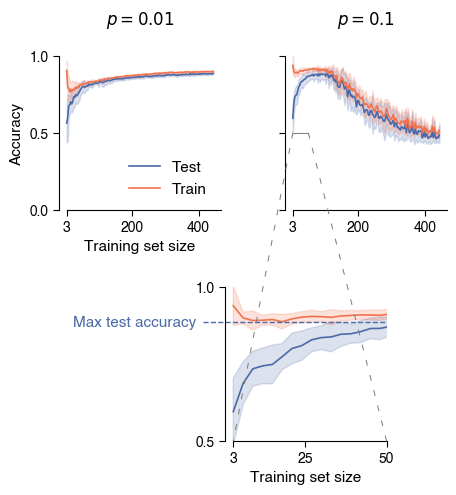

In [176]:
from matplotlib.patches import ConnectionPatch

n_cats_single = 3
show_zoom_boundary = True  # show horizontal line at y=0.5 connecting to zoom

fig, ax = plt.subplots(2, 2, figsize=(5, 5),
                       gridspec_kw={'wspace': 0.4, 'hspace': 0.5})

x_single = np.arange(1, all_test_accs_single.shape[1] + 1) * n_cats_single
x_single_p01 = np.arange(1, single_p01['test_accs'].shape[1] + 1) * n_cats_single

for row in range(2):
    for col, (data, x, p_label) in enumerate([
        (single, x_single, '$p = 0.01$'),
        (single_p01, x_single_p01, '$p = 0.1$'),
    ]):
        if row == 1 and col == 0:
            continue  # skip bottom-left
        a = ax[row, col]
        mt = data['test_accs'].mean(axis=0)
        st = data['test_accs'].std(axis=0)
        mr = data['train_accs'].mean(axis=0)
        sr = data['train_accs'].std(axis=0)
        a.plot(x, mt, '-', color='C0', label='Test')
        a.fill_between(x, mt - st, mt + st, alpha=0.2, color='C0')
        a.plot(x, mr, '-', color='C1', label='Train')
        a.fill_between(x, mr - sr, mr + sr, alpha=0.2, color='C1')
        a.set_ylim(0, 1)
        a.set_yticks([0, 0.5, 1])
        if row == 0:
            a.set_xlim(-20, None)
            a.set_xticks([3, 200, 400])
            a.set_title(p_label, fontsize=12, y=1.15)
        else:
            a.set_xlim(3, 50)
            a.set_xticks([3, 25, 50])
        if col == 0:
            a.set_ylabel('Accuracy', fontsize=11)
        a.spines['bottom'].set_bounds((3, a.get_xlim()[1]))

ax[0, 0].set_xlabel('Training set size', fontsize=11)
ax[1, 1].set_xlabel('Training set size', fontsize=11)
ax[0, 1].set_yticks([0, 0.5, 1], labels=[])
# Hide bottom-left subplot
ax[1, 0].set_visible(False)

# Add ylabel and ticks to bottom-right subplot
# ax[1, 1].set_ylabel('Accuracy', fontsize=11)
ax[1, 1].yaxis.set_tick_params(labelleft=True)
ax[1, 1].set_ylim(0.5, 1)

ax[0, 0].legend(loc='lower right', frameon=False, fontsize=11)
#
# # Legend in the empty bottom-left space
# handles, labels = ax[0, 0].get_legend_handles_labels()
# pos = ax[1, 0].get_position()
# fig.legend(handles, labels, loc='upper right',
#            bbox_to_anchor=(pos.x0 + pos.width / 2, pos.y0 + pos.height / 2),
#            frameon=False, fontsize=11)

# Connecting lines from top-right to bottom-right at x=3 and x=50
for xval in [3, 50]:
    con = ConnectionPatch(
        xyA=(xval, 0.5 if show_zoom_boundary else 0), coordsA=ax[0, 1].transData,
        xyB=(xval, ax[1,1].get_ylim()[0]), coordsB=ax[1, 1].transData,
        color='grey', linewidth=0.75, linestyle=(0, (5, 10)))
    fig.add_artist(con)

# Horizontal line at y=0.5 in top-right plot (zoom boundary)
if show_zoom_boundary:
    ax[0, 1].hlines(0.5, 3, 50, color='grey', linewidth=0.75, linestyle='-')

# Dashed horizontal line at max mean test accuracy in bottom plot
mt_p01 = single_p01['test_accs'].mean(axis=0)
max_acc = mt_p01.max()
ax[1, 1].axhline(max_acc, color='C0', linewidth=1., linestyle='--', clip_on=False,
                  xmin=-0.14, xmax=1.)
ax[1, 1].text(-0.18, max_acc, 'Max test accuracy', transform=ax[1, 1].get_yaxis_transform(),
              fontsize=11, color='C0', va='center', ha='right')

# Shift bottom-right subplot to the left by some amount
pos = ax[1, 1].get_position()
ax[1, 1].set_position([pos.x0 - 0.12, pos.y0, pos.width, pos.height])

# Separate y axis in the bottom subplot
ax[1, 1].set_xlim(0.5, 50)
ax[1, 1].spines['bottom'].set_bounds((3, ax[1, 1].get_xlim()[1]))


# Panel labels
# ax[0, 0].text(-0.23, 1.05, 'a)', transform=ax[0, 0].transAxes,
#               fontsize=12, ha='right', va='bottom')
# ax[1, 1].text(-0.23, 1.05, 'b)', transform=ax[1, 1].transAxes,
#               fontsize=12, ha='right', va='bottom')

plt.savefig('figs/few_shot_zoom_centered.pdf', bbox_inches='tight')
plt.show()

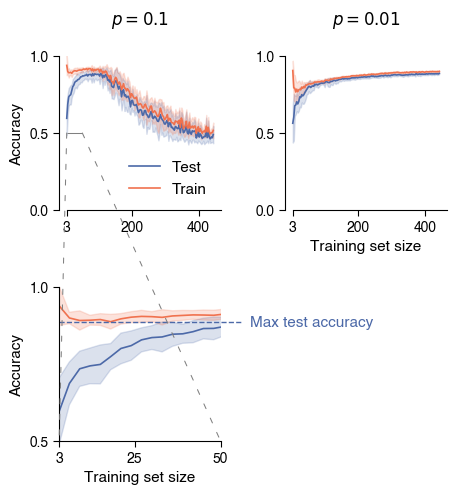

In [153]:
from matplotlib.patches import ConnectionPatch

n_cats_single = 3

fig, ax = plt.subplots(2, 2, figsize=(5, 5),
                       gridspec_kw={'wspace': 0.4, 'hspace': 0.5})

x_single = np.arange(1, all_test_accs_single.shape[1] + 1) * n_cats_single
x_single_p01 = np.arange(1, single_p01['test_accs'].shape[1] + 1) * n_cats_single

for row in range(2):
    for col, (data, x, p_label) in enumerate([
        (single_p01, x_single_p01, '$p = 0.1$'),
        (single, x_single, '$p = 0.01$'),
    ]):
        if row == 1 and col == 1:
            continue  # skip bottom-right
        a = ax[row, col]
        mt = data['test_accs'].mean(axis=0)
        st = data['test_accs'].std(axis=0)
        mr = data['train_accs'].mean(axis=0)
        sr = data['train_accs'].std(axis=0)
        a.plot(x, mt, '-', color='C0', label='Test')
        a.fill_between(x, mt - st, mt + st, alpha=0.2, color='C0')
        a.plot(x, mr, '-', color='C1', label='Train')
        a.fill_between(x, mr - sr, mr + sr, alpha=0.2, color='C1')
        a.set_ylim(0, 1)
        a.set_yticks([0, 0.5, 1])
        if row == 0:
            a.set_xlim(-20, None)
            a.set_xticks([3, 200, 400])
            a.set_title(p_label, fontsize=12, y=1.15)
        else:
            a.set_xlim(3, 50)
            a.set_xticks([3, 25, 50])
            a.set_xlabel('Training set size', fontsize=11)
        if col == 0:
            a.set_ylabel('Accuracy', fontsize=11)
        a.spines['bottom'].set_bounds((3, a.get_xlim()[1]))

ax[0, 1].set_xlabel('Training set size', fontsize=11)

# Hide bottom-right subplot
ax[1, 1].set_visible(False)

# Add ylabel and ticks to bottom-left subplot
ax[1, 0].set_ylabel('Accuracy', fontsize=11)
ax[1, 0].set_ylim(0.5, 1)

ax[0, 0].legend(loc='lower right', frameon=False, fontsize=11)

# # Legend in the empty bottom-right space
# handles, labels = ax[0, 0].get_legend_handles_labels()
# pos = ax[1, 1].get_position()
# fig.legend(handles, labels, loc='lower right',
#            bbox_to_anchor=(pos.x0 + pos.width / 2, pos.y0 + pos.height / 2),
#            frameon=False, fontsize=11)

# Connecting lines from top-left to bottom-left at x=3 and x=50
for xval in [3, 50]:
    con = ConnectionPatch(
        xyA=(xval, 0.5), coordsA=ax[0, 0].transData,
        xyB=(xval, ax[1,0].get_ylim()[0]), coordsB=ax[1, 0].transData,
        color='grey', linewidth=0.75, linestyle=(0, (5, 10)))
    fig.add_artist(con)

# Horizontal line at y=0.5 in top-left plot
ax[0, 0].hlines(0.5, 3, 50, color='grey', linewidth=0.75, linestyle='-')

# Dashed horizontal line at max mean test accuracy in bottom plot
mt_p01 = single_p01['test_accs'].mean(axis=0)
max_acc = mt_p01.max()
ax[1, 0].axhline(max_acc, color='C0', linewidth=1., linestyle='--', clip_on=False,
                  xmin=0., xmax=1.14)
ax[1, 0].text(1.18, max_acc, 'Max test accuracy', transform=ax[1, 0].get_yaxis_transform(),
              fontsize=11, color='C0', va='center', ha='left')

# Panel labels
# ax[0, 0].text(-0.23, 1.05, 'a)', transform=ax[0, 0].transAxes,
#               fontsize=12, ha='right', va='bottom')
# ax[1, 0].text(-0.23, 1.05, 'b)', transform=ax[1, 0].transAxes,
#               fontsize=12, ha='right', va='bottom')

plt.savefig('figs/few_shot_zoom_inv.pdf', bbox_inches='tight')
plt.show()

In [59]:
n_cats_single = 3

# Training set sizes are multiples of 3; show every 9 (every 3 picks)
step = 9 // n_cats_single  # every 3 picks

header = f"{'Size':>6s}  {'p=0.01':>14s}  {'p=0.1':>14s}"
print(header)
print('-' * len(header))

mt_001 = single['test_accs'].mean(axis=0)
st_001 = single['test_accs'].std(axis=0)
mt_01 = single_p01['test_accs'].mean(axis=0)
st_01 = single_p01['test_accs'].std(axis=0)

n_picks = min(mt_001.shape[0], mt_01.shape[0])
for pick in range(step - 1, n_picks, step):
    size = (pick + 1) * n_cats_single
    print(f"{size:>6d}  {mt_001[pick]:.3f} ± {st_001[pick]:.3f}  {mt_01[pick]:.3f} ± {st_01[pick]:.3f}")

  Size          p=0.01           p=0.1
--------------------------------------
     9  0.678 ± 0.068  0.735 ± 0.057
    18  0.689 ± 0.056  0.774 ± 0.043
    27  0.730 ± 0.064  0.828 ± 0.039
    36  0.748 ± 0.058  0.847 ± 0.039
    45  0.783 ± 0.033  0.865 ± 0.034
    54  0.802 ± 0.043  0.870 ± 0.026
    63  0.806 ± 0.028  0.881 ± 0.028
    72  0.813 ± 0.014  0.880 ± 0.030
    81  0.817 ± 0.019  0.885 ± 0.029
    90  0.824 ± 0.009  0.882 ± 0.028
    99  0.825 ± 0.028  0.881 ± 0.031
   108  0.830 ± 0.026  0.882 ± 0.036
   117  0.837 ± 0.020  0.864 ± 0.051
   126  0.843 ± 0.016  0.843 ± 0.067
   135  0.843 ± 0.017  0.861 ± 0.052
   144  0.848 ± 0.011  0.795 ± 0.075
   153  0.854 ± 0.009  0.840 ± 0.083
   162  0.853 ± 0.011  0.803 ± 0.079
   171  0.853 ± 0.009  0.773 ± 0.085
   180  0.858 ± 0.010  0.748 ± 0.079
   189  0.859 ± 0.013  0.738 ± 0.064
   198  0.858 ± 0.007  0.708 ± 0.044
   207  0.861 ± 0.009  0.680 ± 0.067
   216  0.864 ± 0.010  0.656 ± 0.046
   225  0.863 ± 0.008  0.652 ± 0.0

In [60]:
n_cats_single = 3

header = f"{'Size':>6s}  {'p=0.01':>14s}  {'p=0.1':>14s}"
print(header)
print('-' * len(header))

mt_001 = single['test_accs'].mean(axis=0)
st_001 = single['test_accs'].std(axis=0)
mt_01 = single_p01['test_accs'].mean(axis=0)
st_01 = single_p01['test_accs'].std(axis=0)

for pick in range(0, 99 // n_cats_single):
    size = (pick + 1) * n_cats_single
    print(f"{size:>6d}  {mt_001[pick]:.3f} ± {st_001[pick]:.3f}  {mt_01[pick]:.3f} ± {st_01[pick]:.3f}")

  Size          p=0.01           p=0.1
--------------------------------------
     3  0.564 ± 0.125  0.596 ± 0.109
     6  0.602 ± 0.152  0.687 ± 0.070
     9  0.678 ± 0.068  0.735 ± 0.057
    12  0.682 ± 0.060  0.744 ± 0.058
    15  0.703 ± 0.061  0.749 ± 0.063
    18  0.689 ± 0.056  0.774 ± 0.043
    21  0.704 ± 0.061  0.801 ± 0.050
    24  0.735 ± 0.065  0.810 ± 0.048
    27  0.730 ± 0.064  0.828 ± 0.039
    30  0.749 ± 0.050  0.836 ± 0.039
    33  0.741 ± 0.052  0.838 ± 0.049
    36  0.748 ± 0.058  0.847 ± 0.039
    39  0.762 ± 0.058  0.848 ± 0.031
    42  0.772 ± 0.050  0.855 ± 0.036
    45  0.783 ± 0.033  0.865 ± 0.034
    48  0.793 ± 0.038  0.866 ± 0.037
    51  0.803 ± 0.031  0.872 ± 0.031
    54  0.802 ± 0.043  0.870 ± 0.026
    57  0.796 ± 0.032  0.874 ± 0.020
    60  0.803 ± 0.031  0.875 ± 0.026
    63  0.806 ± 0.028  0.881 ± 0.028
    66  0.804 ± 0.025  0.870 ± 0.034
    69  0.817 ± 0.011  0.879 ± 0.026
    72  0.813 ± 0.014  0.880 ± 0.030
    75  0.816 ± 0.012  0.881 ± 0.0